# <center> Machine Learning in Computational Biology - Assignment #1</center>
### <center>*Spring 2026*</center>
### <center>*Epigenetic Age Prediction from DNA Methylation*</center>

---


### Libraries

In [1]:
from functions import *
sys.path.append(os.path.abspath("../src"))
print("Libraries successfully loaded")

Libraries successfully loaded


# Task 1 : Data Loading and Preprocessing
---

## 1.1 Data splitting



### a) Loading the data

In [2]:
dev_data,eval_data=loading_files("../data/development_data.csv","../data/evaluation_data.csv")

Development set (456, 1003)            age             ethnicity sex  cg16867657  cg06639320  cg24724428  \
sample_id                                                                      
GSM990554   79  Caucasian - European   M    0.672001    0.504461    0.331257   
GSM990278   46    Hispanic - Mexican   M    0.555411    0.389214    0.160708   
GSM990589   78  Caucasian - European   M    0.781318    0.554360    0.337578   
GSM990323   46    Hispanic - Mexican   F    0.542491    0.435584    0.228723   
GSM990116   59    Hispanic - Mexican   F    0.653190    0.466217    0.208453   

           cg07553761  cg22454769  cg06784991  cg21572722  ...  cg17321954  \
sample_id                                                  ...               
GSM990554    0.327287    0.572867    0.309496    0.444902  ...    0.174936   
GSM990278    0.230875    0.464971    0.223665    0.381837  ...    0.154691   
GSM990589    0.437668    0.645529    0.309615    0.505999  ...    0.213999   
GSM990323    0.231709

### b) Splitting the data
#### ~80% training - 20% validation split (stratified by age, seed=42)

In [3]:
train_data,val_data,eval_data=split_data(dev_data,eval_data)

        Split  Samples  Percentage
0       Train      364   79.824561
1  Validation       92   20.175439


## 1.2  Preprocessing

### Feature Handling

In [4]:
# Gathering feature groups
metadata,cpg,age=feature_gathering(dev_data)
print(f"Feature Info: \n Metadata:{metadata},CpG columns:{len(cpg)},Column of focus: {age}")
#Create feature sets
metadata_features = feature_set(dev_data, sets="metadata")
cpg_features = feature_set(dev_data, sets="cpg")
all_features = feature_set(dev_data, sets="all")
print("=====================")
print(f"Feature Count: \n Metadata:{len(metadata_features)}, CpG columns:{len(cpg_features)}, Total Features: {len(all_features)}")


Feature Info: 
 Metadata:['sex', 'ethnicity'],CpG columns:1000,Column of focus: age
Feature Count: 
 Metadata:2, CpG columns:1000, Total Features: 1002


## Feature Matrix

#### a) Feature scaling use of StandardScaler to CpG features inside a sklearn Pipeline
#### b) Categorical features: Metadata columns are categorical resulting in the use of encoding for numerical representation.

In [5]:
results, summary_df = feature_matrices(train_data, val_data, eval_data)
summary_df

,feature_set,train,train_processed,val,val_processed,evaluation,evaluation_processed
0,metadata,"(364, 2)","(364, 4)","(92, 2)","(92, 4)","(100, 2)","(100, 4)"
1,cpg,"(364, 1000)","(364, 1000)","(92, 1000)","(92, 1000)","(100, 1000)","(100, 1000)"
2,all,"(364, 1002)","(364, 1004)","(92, 1002)","(92, 1004)","(100, 1002)","(100, 1004)"


## 1.3 Exploratory Analysis

## Dataset statistics table


In [6]:
stats_tab = data_summary(train_data,val_data,eval_data,results=results,features="all")
stats_tab

,dataset,samples,age_mean ± std,age_range,sex_balance,ethnicity_balance,total_missing_values_raw,processed_shape,total_missing_values_processed
0,Train,364,64.5 ± 14.6,19 - 101,"{'M': 191, 'F': 173}","{'Caucasian - European': 246, 'Hispanic - Mexi...",10965,"(364, 1004)",0
1,Validation,92,64.2 ± 14.7,25 - 89,"{'F': 51, 'M': 41}","{'Caucasian - European': 62, 'Hispanic - Mexic...",2747,"(92, 1004)",0
2,Evaluation,100,62.5 ± 14.3,21 - 92,"{'F': 58, 'M': 42}","{'Caucasian - European': 56, 'Hispanic - Mexic...",3058,"(100, 1004)",0


## Age Distribution Plot of Development Dataset


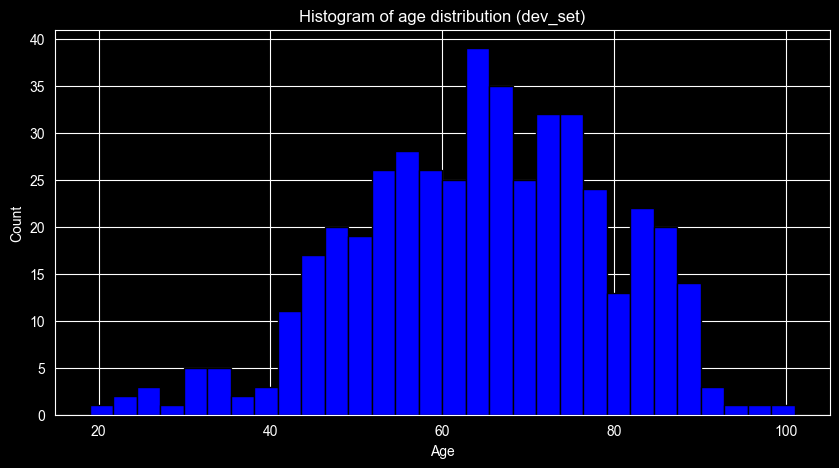

In [7]:
age_distribution_plot(dev_data["age"])

## Age Distribution Plots of Each Dataset

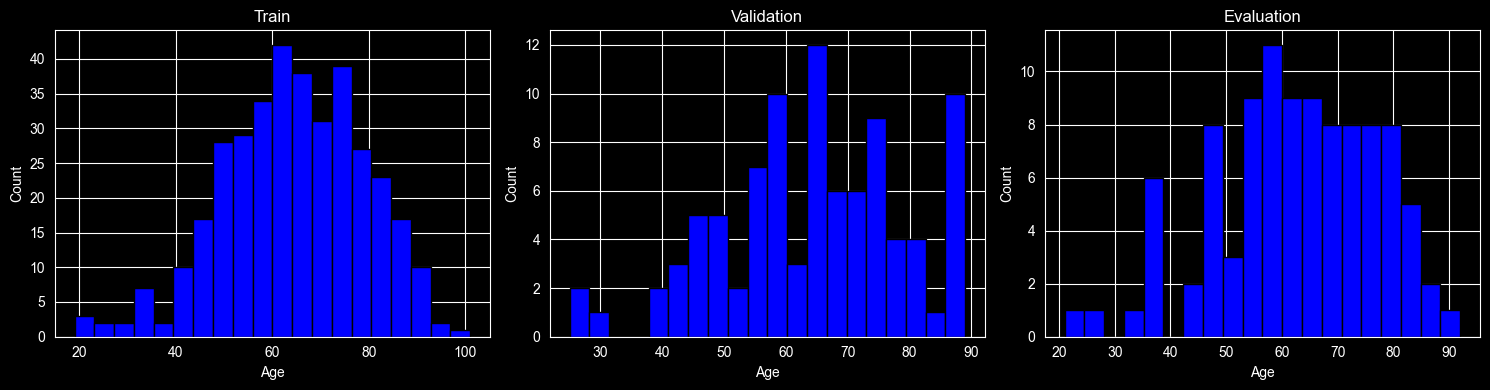

In [8]:
age_split_plot(train_data,val_data,eval_data)

---

# Task 2: Baseline Models
---

 ## 2.1  OLS LinearRegression across feature sets
#### a) Train OLS LinearRegression model per feature set
#### b) Evaluation on the validation set using bootstrap resampling of the validation predictions (1000 resamples, seed=42)


In [7]:
ols_results,ols_summary=ols_all_featuresets(results,n_bootstrap=1000,seed=42)
ols_summary

Evaluation completed
Train OLS LinearRegression for metadata
Evaluation completed
Train OLS LinearRegression for cpg
Evaluation completed
Train OLS LinearRegression for all


,feature_set,RMSE,RMSE_95CI,MAE,MAE_95CI,R2,R2_95CI,Pearson_r,Pearson_95CI
0,metadata,12.9545,10.5730 - 15.4597,9.8540,8.2067 - 11.7093,0.2138,0.0510 - 0.3648,0.4629,0.2991 - 0.6253
1,cpg,5.2731,4.0635 - 6.5458,4.0006,3.2965 - 4.6899,0.8697,0.7875 - 0.9235,0.9355,0.8930 - 0.9650
2,all,5.2576,4.0582 - 6.5256,3.9915,3.2988 - 4.6716,0.8705,0.7878 - 0.9243,0.9360,0.8937 - 0.9654


## 2.2  Three regression models at default hyperparameters
#### a) ElasticNet - L1+L2 regularized linear regression
#### b) SVR - Support Vector Regression with RBF kernel
#### c) BayesianRidge - Bayesian Linear regression
---

### **Training the 3 algorithms at default hyperparameters on the CpG-only feature set**

#### a) CpG-only feature set

In [8]:
X_train_cpg = results["cpg"]["X_train_processed"]
X_val_cpg = results["cpg"]["X_val_processed"]
y_train = results["cpg"]["y_train"]
y_val = results["cpg"]["y_val"]

#### b) Training

In [9]:
#ElasticNet
elastic_model, elastic_pred = model_elasticnet(X_train_cpg, y_train, X_val_cpg)
elastic_results = evaluation_of_model(y_val, elastic_pred)
#SVR
svr_fit, svr_pred = svr_model(X_train_cpg, y_train, X_val_cpg)
svr_results = evaluation_of_model(y_val, svr_pred)
#BayesianRidge
bayes_model, bayes_pred = bayesianridge_model(X_train_cpg, y_train, X_val_cpg)
bayes_results = evaluation_of_model(y_val, bayes_pred)

############### Training ElasticNet ###############
Evaluation completed
############### Training SVR ###############
Evaluation completed
############### Training BayesianRidge ###############
Evaluation completed


#### Creating dict with the results for report table/boxplot

In [12]:
task22_results = {
    "OLS": ols_results["cpg"]["metrics"],
    "ElasticNet": elastic_results,
    "SVR": svr_results,
    "BayesianRidge": bayes_results
}

### **Models Comparison with the OLS floor**
#### Table with RMSE mean, 95% CI, MAE, R², and Pearson r for all baselines


In [21]:
report_df = report_table(task22_results)
#report_df

Report table of model performance:
        Model RMSE mean      RMSE 95% CI MAE mean      MAE 95% CI R² mean       R² 95% CI Pearson r mean Pearson r 95% CI
          OLS    5.2279  4.0635 - 6.5458   3.9824 3.2965 - 4.6899  0.8669 0.7875 - 0.9235         0.9351  0.8930 - 0.9650
   ElasticNet    5.4901  4.3695 - 6.8731   4.0946 3.3488 - 4.8785  0.8538 0.7707 - 0.9109         0.9325  0.8886 - 0.9632
          SVR    8.8880 7.2349 - 10.6252   6.4898 5.3430 - 7.8107  0.6239 0.5374 - 0.7041         0.8466  0.7804 - 0.8984
BayesianRidge    4.6876  3.6219 - 5.9787   3.5233 2.9191 - 4.1763  0.8928 0.8252 - 0.9401         0.9496  0.9134 - 0.9734


### Comparison bootstrap boxplots for RMSE and R² for all models

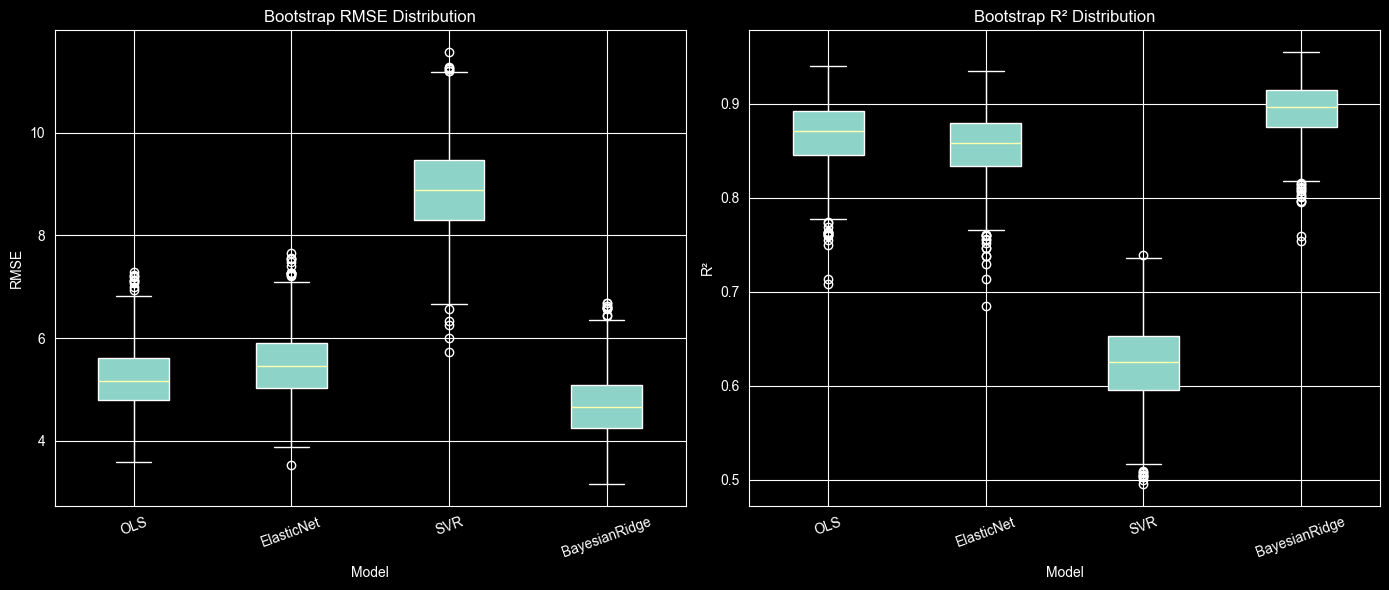

In [16]:
bootstrap_boxplots(task22_results)

#### Comparison of RMSE & R² shows: **BayesianRidge beating the OLS floor**

In [17]:
comparison_df = compare_with_ols({"ElasticNet": elastic_results,"SVR": svr_results,"BayesianRidge": bayes_results},
    ols_results["cpg"]["metrics"])
comparison_df

,Model,RMSE,R²,Beats OLS
0,ElasticNet,5.5131,0.8576,False
1,SVR,8.9233,0.6270,False
2,BayesianRidge,4.7284,0.8953,True


### Additional Analysis: Train vs Validation Performance

In [19]:
#Checking for overfitting
models = {"OLS": ols_results["cpg"]["model"],"EN": elastic_model,"SVR": svr_fit,"BR": bayes_model}
train_val = train_vs_val_all_models(models, X_train_cpg, y_train, X_val_cpg, y_val)
train_val

,Model,Train RMSE,Val RMSE,Train R^2,Val R^2
0,OLS,7.348968e-14,5.273076,1.000000,0.869735
1,EN,3.841868e+00,5.513114,0.930916,0.857606
2,SVR,8.414715e+00,8.923338,0.668584,0.626962
3,BR,1.132770e+00,4.728381,0.993994,0.895257


#### **_Comment_** --> BayesianRidge seems to achieve better generalization with smaller train-validation gaps than OLS that seems to overfitting.

---


# Task 3: Feature Selection
---

## 3.1  Stability Selection

In [ ]:
stable_features,selections_counts=stability_selection(X_train)
frequencyplot(selections_counts)


## 3.2   Minimum Redundancy Maximum Relevance  (mRMR)

### Choosing a K value

In [ ]:
b_k,results = choosing_k_value(X_train,X_val)
results

### Running mRMR with best choosen K

In [ ]:
mrmr_features,top10_mrmr=mrmr_function(X_train,b_k)


### Overlap between Stability & mRMR

In [ ]:
overlapping_plot(stable_features.index,mrmr_features)

## 3.3  Method comparison & Selection

In [ ]:
comparison_df,selected_features,selected_method=feature_comparison(X_train,X_val,stable_features,mrmr_features,b_k)

---

# Task 4: Hyperparameter Tuning and Final Evaluation

----

## 4.1  Hyperparameter tuning

In [ ]:
#Tuning
best_models,tuning_results=model_tuning(dev_data,selected_features,trails=40,seed=42)
tuning_results

## 4.2  Final model evaluation

### Tuned models & Results

In [ ]:
elastic_tuned_results = evaluation(best_models["ElasticNet"],eval_data,selected_features)
svr_tuned_results = evaluation(best_models["SVR"],eval_data,selected_features)
bayes_tuned_results = evaluation(best_models["BayesianRidge"],eval_data,selected_features)
# Tuned results all together
tuned_results={"ElasticNet":elastic_tuned_results,"SVR":svr_tuned_results,"BayesianRidge":bayes_tuned_results}

In [ ]:
bootstrap_boxplots_4_2(tuned_results)
scatter_plot_realvspredicted(best_models,eval_data,selected_features)

### Stage Tables

In [ ]:
elastic_fs,svr_fs,bayes_fs=fs_eval_models(X_train,X_val,selected_features)

In [ ]:
elastic_stage_results = {"Baseline": elastic_results,"FS-only": elastic_fs,"FS+Tuned": elastic_tuned_results}
elastic_stage_table = query_table("ElasticNet", elastic_stage_results)
elastic_stage_table

In [ ]:
svr_stage_results = {"Baseline": svr_results,"FS-only": svr_fs,"FS+Tuned": svr_tuned_results}
svr_stage_table = query_table("SVR", svr_stage_results)
svr_stage_table

In [ ]:
bayes_stage_results ={"Baseline":bayes_results,"Fs-only":bayes_fs,"Fs+only":bayes_tuned_results}
bayes_stage_table = query_table("BayesianRidge", bayes_stage_results)
bayes_stage_table

### Fs-only evaluation

In [ ]:
elastic_fs, svr_fs, bayes_fs = fs_eval_models(X_train,X_val,selected_features)

## 4.3  Model selection and final model

In [ ]:
tuned_results = {"ElasticNet": elastic_tuned_results,"SVR": svr_tuned_results,"BayesianRidge": bayes_tuned_results}
tuned_models = {"ElasticNet": best_models["ElasticNet"],"SVR": best_models["SVR"],"BayesianRidge": best_models["BayesianRidge"]}
best_model_name, best_model, best_model_path = selection_save_final(tuned_results=tuned_results,tuned_models=tuned_models)

## Best Model Results

In [ ]:
X_eval = eval_data[selected_features]
y_eval = eval_data["age"].values
y_predict = best_model.predict(X_eval)
plot_best_model_real_predict(y_eval, y_predict, best_model_name)